# Preprocessing LinkedIn Data Jobs Dataset Folder 

## Alur (Belum Fix)
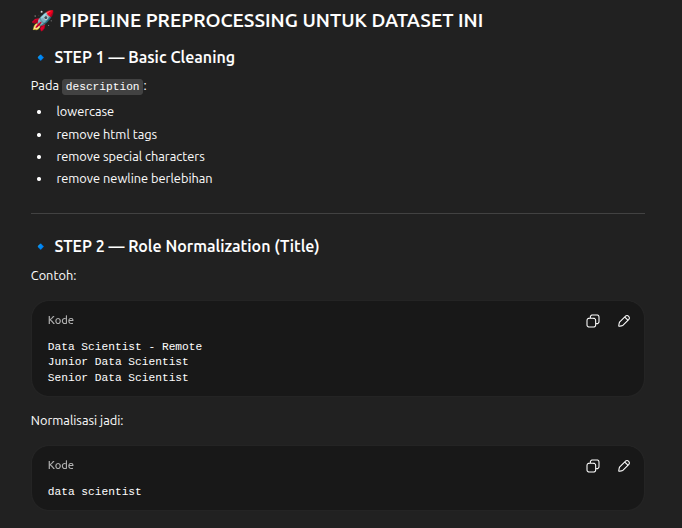
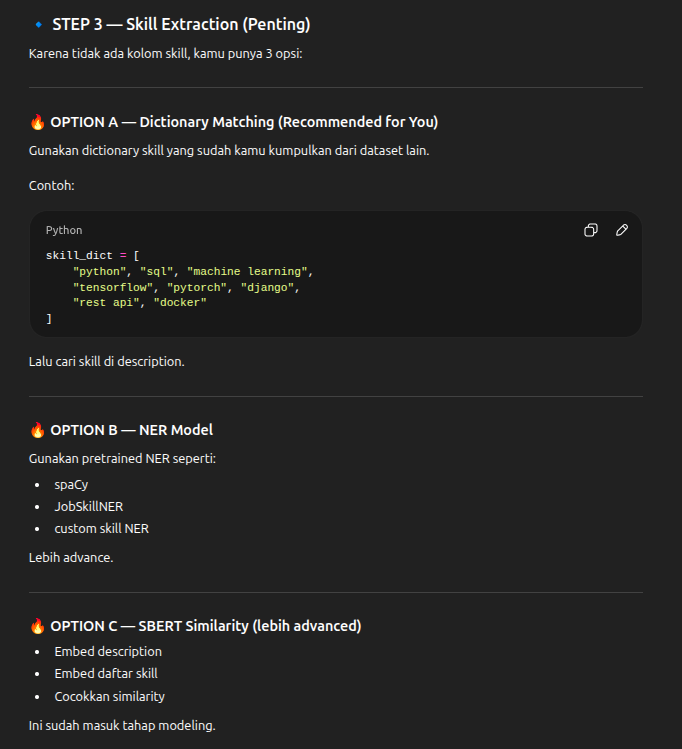
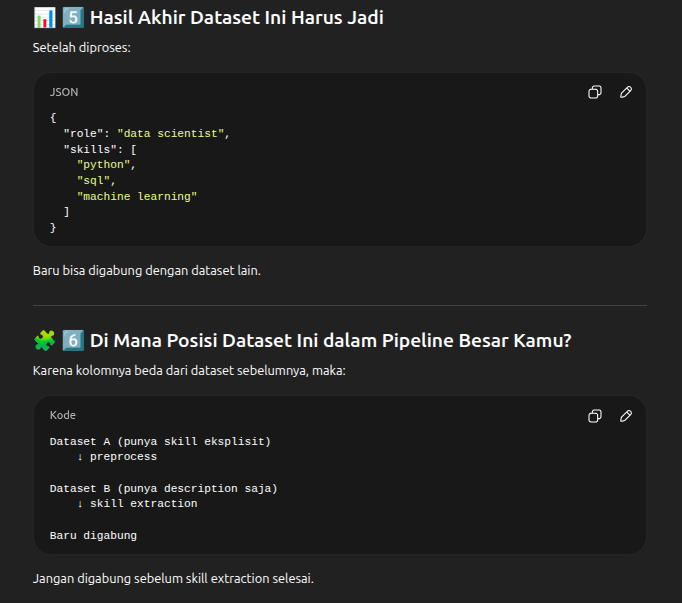
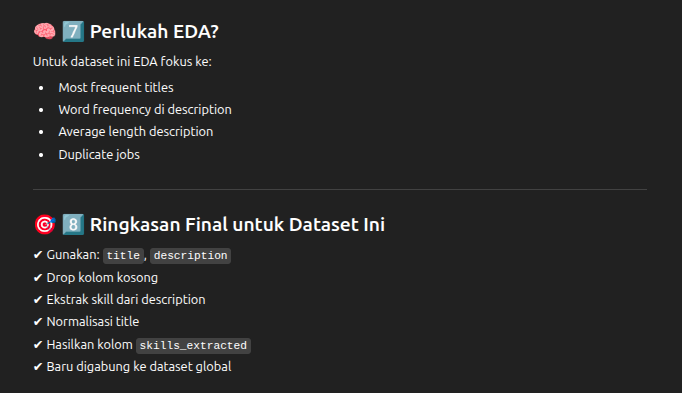

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
id = '18U6rB-OoH4ZvgGBF2V8nVUDMyDtD1dCQ'
url = f'https://drive.google.com/uc?id={id}'
df = pd.read_csv(url)
df.head()

,id,title,company,location,link,source,date_posted,work_type,employment_type,description
0,1,Data Analyst,Meta,"New York, NY",https://www.linkedin.com/jobs/view/data-analys...,LinkedIn,2025-04-14,NaN,NaN,The Social Measurement team is a growing team ...
1,2,Data Analyst,Meta,"San Francisco, CA",https://www.linkedin.com/jobs/view/data-analys...,LinkedIn,2025-04-14,NaN,NaN,The Social Measurement team is a growing team ...
2,3,Data Analyst,Meta,"Los Angeles, CA",https://www.linkedin.com/jobs/view/data-analys...,LinkedIn,2025-04-14,NaN,NaN,The Social Measurement team is a growing team ...
3,4,Data Analyst,Meta,"Washington, DC",https://www.linkedin.com/jobs/view/data-analys...,LinkedIn,2025-04-14,NaN,NaN,The Social Measurement team is a growing team ...
4,5,Data Analyst II,Pinterest,"Chicago, IL",https://www.linkedin.com/jobs/view/data-analys...,LinkedIn,2025-04-16,NaN,NaN,About Pinterest\n\nMillions of people around t...


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048 entries, 0 to 1047
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1048 non-null   int64  
 1   title            1048 non-null   object 
 2   company          1046 non-null   object 
 3   location         1033 non-null   object 
 4   link             1048 non-null   object 
 5   source           959 non-null    object 
 6   date_posted      1025 non-null   object 
 7   work_type        0 non-null      float64
 8   employment_type  0 non-null      float64
 9   description      1044 non-null   object 
dtypes: float64(2), int64(1), object(7)
memory usage: 82.0+ KB


In [4]:
df.columns

Index(['id', 'title', 'company', 'location', 'link', 'source', 'date_posted',
       'work_type', 'employment_type', 'description'],
      dtype='object')

In [5]:
df.drop(columns=['id', 'company', 'location', 'link', 'source',
       'work_type', 'employment_type'], inplace=True)
df.head()

,title,date_posted,description
0,Data Analyst,2025-04-14,The Social Measurement team is a growing team ...
1,Data Analyst,2025-04-14,The Social Measurement team is a growing team ...
2,Data Analyst,2025-04-14,The Social Measurement team is a growing team ...
3,Data Analyst,2025-04-14,The Social Measurement team is a growing team ...
4,Data Analyst II,2025-04-16,About Pinterest\n\nMillions of people around t...


In [6]:
# Proses data null + duplicate
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048 entries, 0 to 1047
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   title        1048 non-null   object
 1   date_posted  1025 non-null   object
 2   description  1044 non-null   object
dtypes: object(3)
memory usage: 24.7+ KB


In [7]:
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 929 entries, 0 to 1047
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   title        929 non-null    object
 1   date_posted  929 non-null    object
 2   description  929 non-null    object
dtypes: object(3)
memory usage: 29.0+ KB


In [8]:
# Role Normalization

def map_role(title):
    title = title.lower()
    
    if 'data analyst' in title:
        return 'data analyst'
    elif 'frontend' in title or 'front end' in title or 'react' in title or 'front-end' in title:
        return 'frontend'
    elif "backend" in title or 'back end' in title or "node" in title or 'back-end' in title:
        return "backend"
    else:
        return None
df['role'] = df['title'].apply(map_role)
df = df[df['role'].notnull()].copy()
df

,title,date_posted,description,role
0,Data Analyst,2025-04-14,The Social Measurement team is a growing team ...,data analyst
2,Data Analyst,2025-04-14,The Social Measurement team is a growing team ...,data analyst
4,Data Analyst II,2025-04-16,About Pinterest\n\nMillions of people around t...,data analyst
5,Data Analyst,2025-04-11,About Fanduel\n\nFanDuel Group is the premier ...,data analyst
6,"Data Analyst, Production Finance Operations & ...",2025-04-10,Netflix is one of the world's leading entertai...,data analyst
...,...,...,...,...
911,Data Analyst II,2025-06-04,**The Role**\n**JOB DESCRIPTION**\n We are see...,data analyst
914,Data Analyst - Construction,2025-06-06,"**Compensation Range**\n $106,700\.00 \- $140,...",data analyst
925,Senior Data Analyst,2025-06-09,**About Us**\n------------\n\n\nSmith.ai build...,data analyst
1003,Data Analyst,2025-06-09,We’re looking for a\n **Real Estate Data Analy...,data analyst


In [9]:
import re

def casefolding(text):
    return text.lower()

def cleaning(text):
    text = re.sub(r"http\S+", "", text)
    
    text = text.replace('\n', ' ')
    text = text.replace('*','')
    text = text.replace('-','')
    
    text = text.strip()
    
    text = re.sub(r'\s+', ' ', text)
    
    return text


df['clean_title'] = df['title'].apply(casefolding)
df['clean_title'] = df['clean_title'].apply(cleaning)

df['clean_description'] = df['description'].apply(casefolding)
df['clean_description'] = df['clean_description'].apply(cleaning)

In [10]:
df

,title,date_posted,description,role,clean_title,clean_description
0,Data Analyst,2025-04-14,The Social Measurement team is a growing team ...,data analyst,data analyst,the social measurement team is a growing team ...
2,Data Analyst,2025-04-14,The Social Measurement team is a growing team ...,data analyst,data analyst,the social measurement team is a growing team ...
4,Data Analyst II,2025-04-16,About Pinterest\n\nMillions of people around t...,data analyst,data analyst ii,about pinterest millions of people around the ...
5,Data Analyst,2025-04-11,About Fanduel\n\nFanDuel Group is the premier ...,data analyst,data analyst,about fanduel fanduel group is the premier mob...
6,"Data Analyst, Production Finance Operations & ...",2025-04-10,Netflix is one of the world's leading entertai...,data analyst,"data analyst, production finance operations & ...",netflix is one of the world's leading entertai...
...,...,...,...,...,...,...
911,Data Analyst II,2025-06-04,**The Role**\n**JOB DESCRIPTION**\n We are see...,data analyst,data analyst ii,the role job description we are seeking a data...
914,Data Analyst - Construction,2025-06-06,"**Compensation Range**\n $106,700\.00 \- $140,...",data analyst,data analyst construction,"compensation range $106,700\.00 \ $140,000\.00..."
925,Senior Data Analyst,2025-06-09,**About Us**\n------------\n\n\nSmith.ai build...,data analyst,senior data analyst,about us smith.ai builds ai voice agents that ...
1003,Data Analyst,2025-06-09,We’re looking for a\n **Real Estate Data Analy...,data analyst,data analyst,we’re looking for a real estate data analyst t...


In [11]:
def remove_irrelevant_sections(text):
    irrelevant_keywords = [
        "equal employment",
        "affirmative action",
        "we do not discriminate",
        "about meta",
        "compensation",
        "benefits",
        "-verify",
        "accomodations"
        "about us"
    ]
    
    for keyword in irrelevant_keywords:
        pattern = re.compile(rf"{keyword}.*", re.IGNORECASE)
        text = pattern.sub("", text)
    
    return text
df['clean_description'] = df['clean_description'].apply(remove_irrelevant_sections)

In [12]:
df

,title,date_posted,description,role,clean_title,clean_description
0,Data Analyst,2025-04-14,The Social Measurement team is a growing team ...,data analyst,data analyst,the social measurement team is a growing team ...
2,Data Analyst,2025-04-14,The Social Measurement team is a growing team ...,data analyst,data analyst,the social measurement team is a growing team ...
4,Data Analyst II,2025-04-16,About Pinterest\n\nMillions of people around t...,data analyst,data analyst ii,about pinterest millions of people around the ...
5,Data Analyst,2025-04-11,About Fanduel\n\nFanDuel Group is the premier ...,data analyst,data analyst,about fanduel fanduel group is the premier mob...
6,"Data Analyst, Production Finance Operations & ...",2025-04-10,Netflix is one of the world's leading entertai...,data analyst,"data analyst, production finance operations & ...",netflix is one of the world's leading entertai...
...,...,...,...,...,...,...
911,Data Analyst II,2025-06-04,**The Role**\n**JOB DESCRIPTION**\n We are see...,data analyst,data analyst ii,the role job description we are seeking a data...
914,Data Analyst - Construction,2025-06-06,"**Compensation Range**\n $106,700\.00 \- $140,...",data analyst,data analyst construction,
925,Senior Data Analyst,2025-06-09,**About Us**\n------------\n\n\nSmith.ai build...,data analyst,senior data analyst,about us smith.ai builds ai voice agents that ...
1003,Data Analyst,2025-06-09,We’re looking for a\n **Real Estate Data Analy...,data analyst,data analyst,we’re looking for a real estate data analyst t...


In [13]:
df['role'].value_counts()

role
data analyst    251
frontend          3
Name: count, dtype: int64

In [14]:
df_final = df[['role', 'clean_description']].copy()
df_final

,role,clean_description
0,data analyst,the social measurement team is a growing team ...
2,data analyst,the social measurement team is a growing team ...
4,data analyst,about pinterest millions of people around the ...
5,data analyst,about fanduel fanduel group is the premier mob...
6,data analyst,netflix is one of the world's leading entertai...
...,...,...
911,data analyst,the role job description we are seeking a data...
914,data analyst,
925,data analyst,about us smith.ai builds ai voice agents that ...
1003,data analyst,we’re looking for a real estate data analyst t...


In [15]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 254 entries, 0 to 1015
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   role               254 non-null    object
 1   clean_description  254 non-null    object
dtypes: object(2)
memory usage: 6.0+ KB


In [16]:
df_final.rename(columns={'clean_description': 'description'}, inplace=True)
df_final

,role,description
0,data analyst,the social measurement team is a growing team ...
2,data analyst,the social measurement team is a growing team ...
4,data analyst,about pinterest millions of people around the ...
5,data analyst,about fanduel fanduel group is the premier mob...
6,data analyst,netflix is one of the world's leading entertai...
...,...,...
911,data analyst,the role job description we are seeking a data...
914,data analyst,
925,data analyst,about us smith.ai builds ai voice agents that ...
1003,data analyst,we’re looking for a real estate data analyst t...
